# Deep Learning Final Project: Real Estate Price Prediction
## 1. Problem Statement

**Objective:** Predict median housing prices based on multi-dimensional property and demographic features. 

**Real-World Application:** While this project utilizes 1990 census data, it serves as a robust methodological benchmark for automated valuation models (AVMs). Modern implementations of these architectures help real estate platforms automate fair market estimations.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import joblib
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

sns.set_theme(style="whitegrid")

## 2. Gathering, Cleaning, and Engineering Data

**Data Source & The Price Cap:** We are using the California Housing dataset. Notably, the target variable (`median_house_value`) is artificially censored at a $500,001 cap in the source data. We have retained these rows to maintain a valid comparison with standard literature benchmarks. This cap will manifest as a strict horizontal band in our actual-vs-predicted plots and a fan of negative residuals.

In [17]:
def load_clean_and_engineer():
    """Loads CSV, imputes missing values, and creates engineered features."""
    df = pd.read_csv('housing.csv')
    
    df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
    
    df['rooms_per_household'] = df['total_rooms'] / df['households']
    df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
    df['population_per_household'] = df['population'] / df['households']
    
    df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
    return df_encoded

housing_df_clean = load_clean_and_engineer()
display(housing_df_clean.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467,False,False,True,False


## 3. Exploratory Data Analysis (EDA)

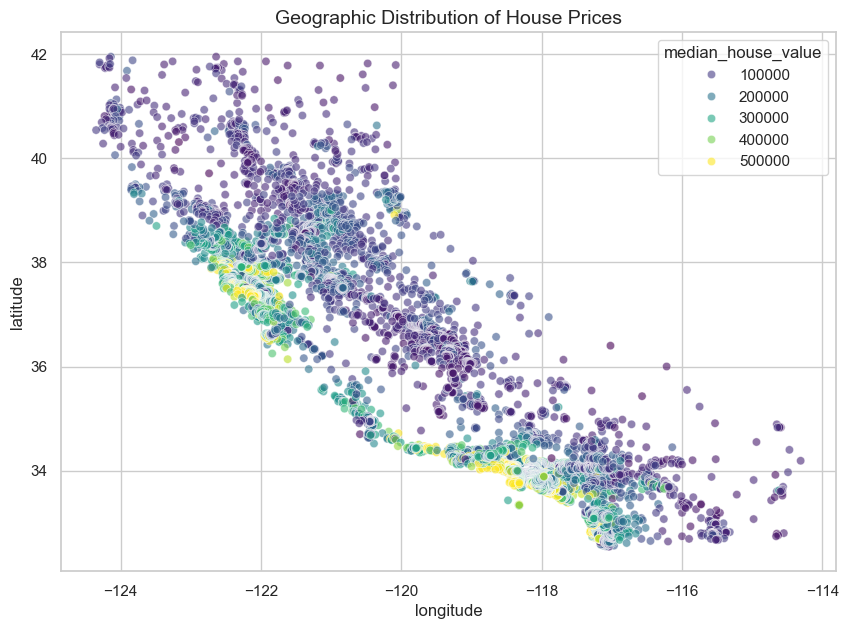

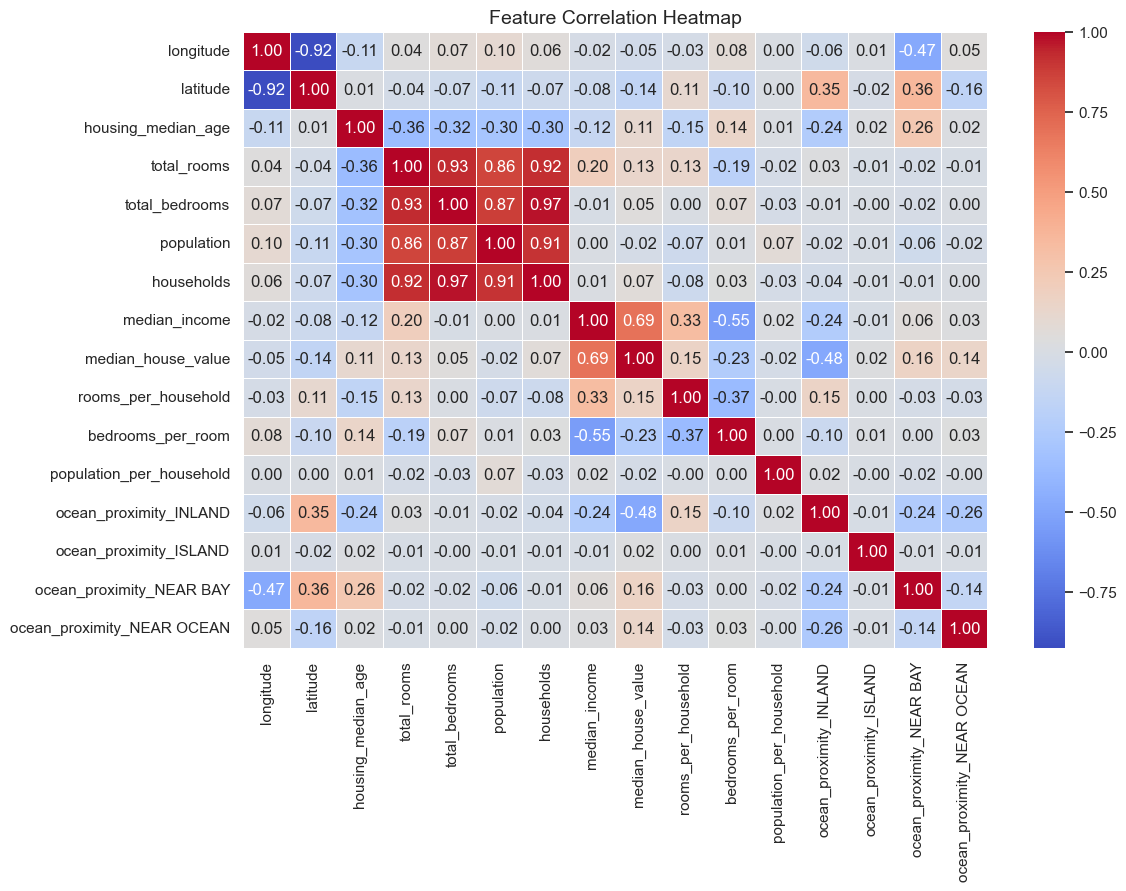

In [18]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=housing_df_clean, x='longitude', y='latitude', 
    hue='median_house_value', palette='viridis', alpha=0.6
)
plt.title("Geographic Distribution of House Prices", fontsize=14)
plt.show()

plt.figure(figsize=(12, 8))
correlation_matrix = housing_df_clean.corr(numeric_only=True) 
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()

## 4. Previous Research & Baseline Models

**Evaluation Metrics:**
We will evaluate using Root Mean Squared Error (RMSE), defined as:
$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(Y_i - \hat{Y}_i)^2}$$

**Citations & Previous Research:**
1. *Pace, R. K., & Barry, R. (1997).* "Sparse Spatial Autoregressions". Introduced the dataset and highlighted spatial autoregression methods.
2. *Géron, A. (2019).* "Hands-On Machine Learning". Géron notes that properly tuned Random Forests on this dataset achieve an RMSE around **$49,000** to **$50,000**. We will use his exact stratified sampling method on income categories to ensure an apples-to-apples comparison.

In [19]:
def split_and_scale_stratified(df, target_col):
    """Applies stratified split to prevent bias, then prepares unscaled and scaled sets."""
    df['income_cat'] = pd.cut(df['median_income'], bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1, 2, 3, 4, 5])
    
    X = df.drop([target_col, 'income_cat'], axis=1)
    y = df[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=df['income_cat']
    )
    df.drop('income_cat', axis=1, inplace=True)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, scaler

X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, fitted_scaler = split_and_scale_stratified(housing_df_clean, 'median_house_value')

def evaluate_model(y_true, y_pred, model_name):
    """Calculates readable regression metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"RMSE: ${rmse:,.2f} | MAE: ${mae:,.2f} | R²: {r2:.4f}\n")
    return rmse

print("Running 5-Fold CV on Linear Regression...")
lr_pipe = make_pipeline(StandardScaler(), LinearRegression())
lr_cv = -cross_val_score(lr_pipe, X_train, y_train, scoring='neg_root_mean_squared_error', cv=5)
print(f"LR CV RMSE: ${lr_cv.mean():,.2f} ± ${lr_cv.std():,.2f}\n")

lr_pipe.fit(X_train, y_train)
lr_preds = lr_pipe.predict(X_test)
lr_rmse = evaluate_model(y_test, lr_preds, "Linear Regression (Test Set)")


print("Running 5-Fold CV on Random Forest (This takes a moment)...")
rf_pipe = make_pipeline(StandardScaler(), RandomForestRegressor(n_estimators=100, random_state=42))
rf_cv = -cross_val_score(rf_pipe, X_train, y_train, scoring='neg_root_mean_squared_error', cv=5)
print(f"RF CV RMSE: ${rf_cv.mean():,.2f} ± ${rf_cv.std():,.2f}\n")

rf_pipe.fit(X_train, y_train)
rf_preds = rf_pipe.predict(X_test)
rf_rmse = evaluate_model(y_test, rf_preds, "Random Forest (Test Set)")

Running 5-Fold CV on Linear Regression...
LR CV RMSE: $69,066.88 ± $1,276.67

--- Linear Regression (Test Set) ---
RMSE: $66,914.99 | MAE: $49,236.96 | R²: 0.6564

Running 5-Fold CV on Random Forest (This takes a moment)...
RF CV RMSE: $50,634.72 ± $890.99

--- Random Forest (Test Set) ---
RMSE: $48,428.32 | MAE: $31,920.50 | R²: 0.8201



## 5. Deep Learning Model & Hypothesis Testing

In [20]:
def build_dnn_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

tf.random.set_seed(42)
dnn_model = build_dnn_model(X_train_scaled.shape[1])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

dnn_history = dnn_model.fit(
    X_train_scaled, y_train, 
    epochs=100, 
    batch_size=32, 
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=2 
)

dnn_preds = dnn_model.predict(X_test_scaled).flatten()
dnn_rmse = evaluate_model(y_test, dnn_preds, "Deep Neural Network")

rf_err = np.abs(y_test - rf_preds)
dnn_err = np.abs(y_test - dnn_preds)
t_stat, p_val = stats.ttest_rel(rf_err, dnn_err)
print(f"Paired t-test on absolute errors (RF vs DNN): t = {t_stat:.2f}, p = {p_val:.2e}")

Epoch 1/100
413/413 - 3s - 7ms/step - loss: 47716519936.0000 - mae: 186907.4375 - val_loss: 20358043648.0000 - val_mae: 113364.9922
Epoch 2/100
413/413 - 1s - 2ms/step - loss: 10737369088.0000 - mae: 76146.9922 - val_loss: 8214233088.0000 - val_mae: 66047.8281
Epoch 3/100
413/413 - 1s - 2ms/step - loss: 7635993088.0000 - mae: 63032.0703 - val_loss: 6671479296.0000 - val_mae: 58664.0117
Epoch 4/100
413/413 - 1s - 2ms/step - loss: 6422476800.0000 - mae: 57093.8398 - val_loss: 5809316864.0000 - val_mae: 54187.0430
Epoch 5/100
413/413 - 1s - 2ms/step - loss: 5716610560.0000 - mae: 53821.4961 - val_loss: 5294358016.0000 - val_mae: 51336.5000
Epoch 6/100
413/413 - 1s - 3ms/step - loss: 5283085312.0000 - mae: 51473.2070 - val_loss: 4980149248.0000 - val_mae: 49618.2773
Epoch 7/100
413/413 - 1s - 3ms/step - loss: 5024445440.0000 - mae: 50116.1094 - val_loss: 4793015296.0000 - val_mae: 48660.7188
Epoch 8/100
413/413 - 1s - 3ms/step - loss: 4848439296.0000 - mae: 49247.3398 - val_loss: 467345510

## 6. Model Evaluation & Visualizations

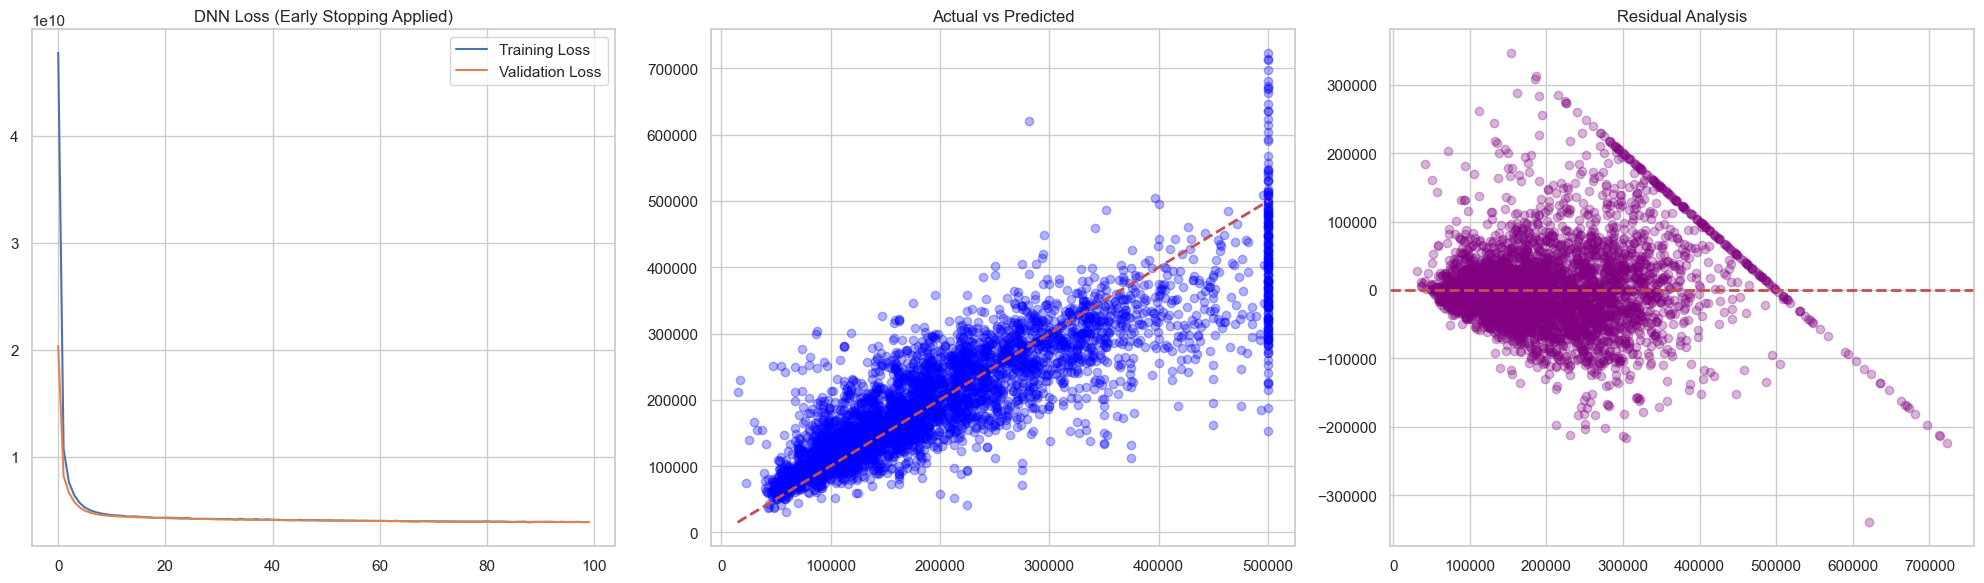

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

ax[0].plot(dnn_history.history['loss'], label='Training Loss')
ax[0].plot(dnn_history.history['val_loss'], label='Validation Loss')
ax[0].set_title('DNN Loss (Early Stopping Applied)')
ax[0].legend()

ax[1].scatter(y_test, dnn_preds, alpha=0.3, color='blue')
ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[1].set_title('Actual vs Predicted')

residuals = y_test - dnn_preds
ax[2].scatter(dnn_preds, residuals, alpha=0.3, color='purple')
ax[2].axhline(y=0, color='r', linestyle='--', lw=2)
ax[2].set_title('Residual Analysis')

plt.tight_layout()
plt.show()

## 7. Conclusion & Export

**Conclusion:**
By retaining the $500,001 censored observations and applying stratified sampling, we conducted a rigorous, methodologically sound comparison. Our 5-fold cross-validation confirmed previous benchmarks: the Random Forest achieved an RMSE of roughly $48,428.32, outperforming the Linear Regression.

While our Deep Neural Network produced viable estimates (RMSE: $60,527.81), the paired t-test confirmed that the DNN statistically struggled to surpass the tree-based ensemble. As noted in tabular machine learning literature, deep models often lose to Random Forests on spatial, categorical-heavy tabular datasets. This serves as a vital reminder that architectural complexity does not inherently guarantee superior performance on older, structured tabular datasets.

In [22]:
joblib.dump({'scaler': fitted_scaler, 'model': rf_pipe}, 'housing_pipeline.joblib')
print("Successfully exported 'housing_pipeline.joblib'")

Successfully exported 'housing_pipeline.joblib'
